['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


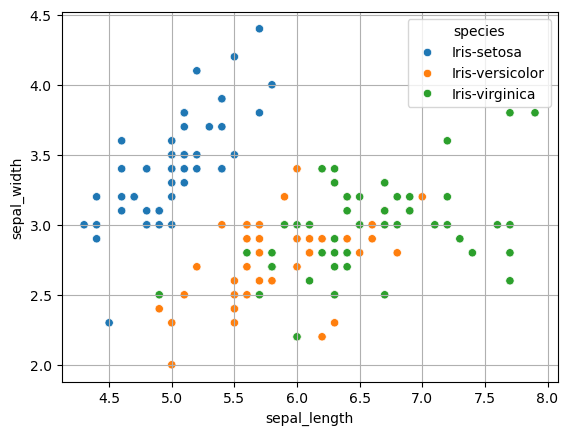

Accuracy Score of SVM= 0.9666666666666667
Accuracy Score of Decision Tree= 0.9666666666666667


<Axes: ylabel='species'>

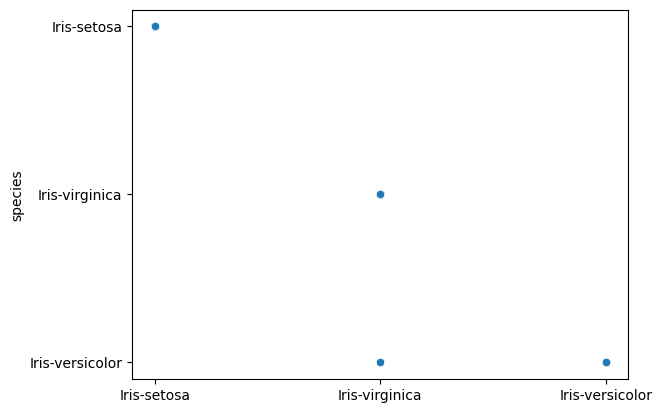

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
dat=pd.read_csv(r'IRIS.csv')
#print(dat['species'])
lec=LabelEncoder()
l_enc=lec.fit_transform(dat['species'])
#print(np.array(l_enc).reshape(-1,1))
print(lec.classes_) #checking which value holds which code
dat['species_code']=l_enc
#print(dat.info())
sns.scatterplot(x='sepal_length',y='sepal_width',hue='species',data=dat,markers='*')
plt.grid()
plt.show()
df_setosa=dat.query("species_code==0")
df_versicolor=dat.query("species_code==1")
df_virginica=dat.query("species_code==2")
X=dat.drop(['species','species_code'],axis='columns')
Y=dat['species']
X_train, X_test, y_train, y_test=train_test_split(X,Y,test_size=0.2,shuffle=True,stratify=Y,random_state=42)
svm=SVC()
svm.fit(X_train,y_train)
pred_svm=svm.predict(X_test)
dtree=tree.DecisionTreeClassifier()
dtree.fit(X_train,y_train)
pred_dt=dtree.predict(X_test)
print("Accuracy Score of SVM=",accuracy_score(y_test,pred_svm))
print("Accuracy Score of Decision Tree=",accuracy_score(y_test,pred_dt))